# Tutorial 4: GRN Analysis

After training, we can extract and analyze the learned Gene Regulatory Network. The model learns two regulatory matrices:

- **tf2r (TF→Region)**: Which TFs bind to which regulatory regions
- **r2g (Region→Gene)**: Which regions regulate which genes

This tutorial shows how to extract these matrices and find key regulatory relationships.

## Setup

In [1]:
import torch

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


/data/groups/vib.ai/stein.aerts/lmahieu/software/miniconda3/envs/deepscenic-dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Model and Data

In [2]:
data_dir = "./data/MM_lines/"

# Load trained model and data
model = ds.tl.load_model(data_dir + "checkpoints/deepscenic_model.pt", device=device)
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

print(f"Model: {len(model.tf_names)} TFs, {len(model.gene_names)} genes")

/data/groups/vib.ai/stein.aerts/lmahieu/software/miniconda3/envs/deepscenic-dev/lib/python3.13/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
deepscenic.tl - INFO - Loaded model from ./data/MM_lines/checkpoints/deepscenic_model.pt: 12158 genes, 1463 TFs, 288552 regions
deepscenic.io - INFO - Loaded data/MM_lines/preprocessed_data.h5mu: 936 cells, 12158 genes, 288643 regions


Model: 1463 TFs, 12158 genes


Based on the SCENIC+ paper, we expect certain TFs to be active in specific cell states:

| Cell State | Expected Active TFs |
|------------|-------------------|
| **MEL** | SOX10, MITF, TFAP2A, RUNX3 |
| **MES** | JUN, NFIB, ZEB1 |
| **INT** | SOX6, EGR3, ETV4 |

## Extract GRN

The GRN consists of two matrices:

- **tf2r (TF->Region)**: TF binding potential to regulatory regions
- **r2g (Region->Gene)**: Region regulatory effect on genes

The combined GRN is tf2r @ r2g, giving TF->Gene regulatory weights.

In [3]:
# Extract the full GRN as a DataFrame
# Returns dict with 'tf2r', 'r2g' DataFrames
grn = ds.tl.extract_grn(model)

print(f"tf2r (TF→Region): {grn['tf2r'].shape}")
print(f"r2g (Region→Gene): {grn['r2g'].shape}")

tf2r (TF→Region): (288552, 1463)
r2g (Region→Gene): (3253274, 3)


## Find TF Targets

Get the target genes for a specific TF, ranked by regulatory weight:

In [4]:
# Find targets of a TF
# Uses Otsu thresholding to identify significant links
targets = ds.tl.get_tf_targets(model, tf_name="SOX10", top_k=20)
targets

deepscenic.tl._grn - INFO - TF 'SOX10': using Otsu tf2r threshold = 0.5385


,tf,region,tf2r_weight,gene,r2g_weight,combined_weight
171411,SOX10,chr12:56082949-56083449,3.426676,PMEL,0.110564,0.378866
8253,SOX10,chr9:6781416-6781916,1.295511,MLANA,0.246936,0.319908
79318,SOX10,chrX:23822329-23822829,3.023619,SAT1,0.067730,0.204789
88590,SOX10,chr13:94479644-94480144,2.588207,DCT,0.072903,0.188687
56288,SOX10,chr1:153100211-153100711,-0.849809,S100A6,0.215822,-0.183408
30351,SOX10,chr7:116271935-116272435,-1.206695,CAV1,0.104066,-0.125575
30725,SOX10,chr18:76771349-76771849,2.708888,MBP,0.044550,0.120680
105570,SOX10,chr9:35518087-35518587,-0.894956,TPM2,0.134714,-0.120563
61933,SOX10,chr3:69926370-69926870,3.144214,MITF,0.037107,0.116673
180962,SOX10,chr16:57194568-57195068,-0.670315,MT2A,0.170366,-0.114199


SOX10 is a master regulator of the melanocytic lineage. Its target genes should include Melanocyte differentiation genes, which is the case here.

## Find Gene Regulators

Get the TFs that regulate a specific gene:

In [5]:
# Find regulators of a gene
regulators = ds.tl.get_gene_regulators(model, gene_name="MITF", top_k=10)
regulators

deepscenic.tl._grn - INFO - Gene 'MITF': using per-TF Otsu thresholds


,gene,tf,region,tf2r_weight,r2g_weight,combined_weight
17205,MITF,MITF,chr3:69926370-69926870,5.418750,0.037107,0.201075
17310,MITF,PIR,chr3:69926370-69926870,4.281834,0.037107,0.158887
16860,MITF,ANXA1,chr3:69926370-69926870,-3.683201,0.037107,-0.136674
17407,MITF,SOX10,chr3:69926370-69926870,3.144214,0.037107,0.116673
17554,MITF,ZCCHC17,chr3:69926370-69926870,2.822813,0.037107,0.104747
17122,MITF,ID2,chr3:69926370-69926870,2.625405,0.037107,0.097422
17227,MITF,MXI1,chr3:69926370-69926870,2.186596,0.037107,0.081139
17410,MITF,SOX4,chr3:69926370-69926870,1.966093,0.037107,0.072956
16932,MITF,CTNNB1,chr3:69926370-69926870,1.915481,0.037107,0.071078
17318,MITF,POLR3G,chr3:69926370-69926870,1.804546,0.037107,0.066962


## Visualize GRN Heatmaps

The combined GRN heatmap shows the TF→gene regulatory weights (tf2r @ r2g), z-score normalized
per TF to highlight gene-specific patterns. For cell-type specific visualization, see the
cell-type aware workflow below.

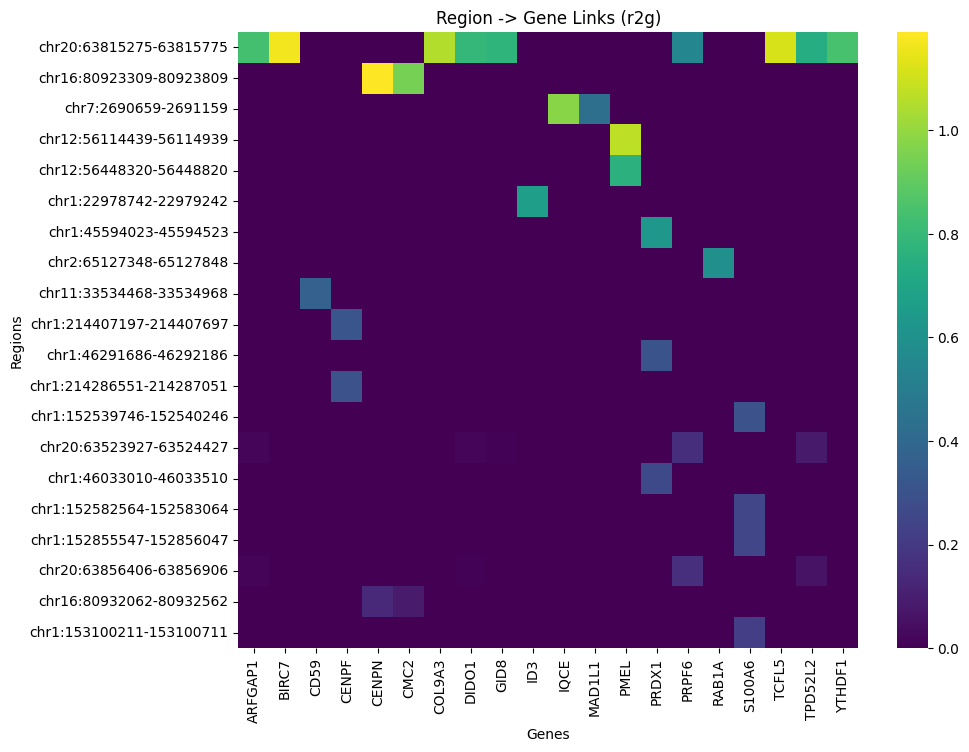

In [6]:
# r2g heatmap (Region->Gene)
ds.pl.heatmap_r2g(model, top_k=20)

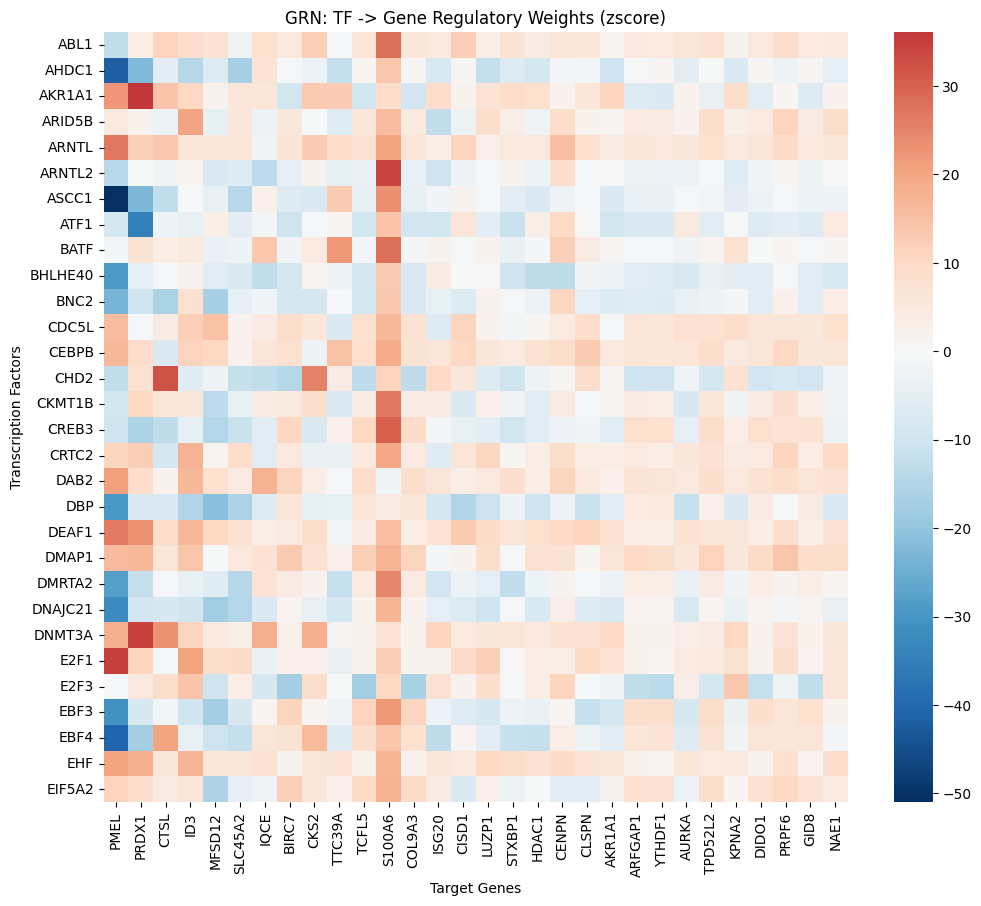

In [7]:
# Combined GRN heatmap (TF->Gene), z-score normalized per TF
ds.pl.heatmap_grn(model, top_k=30)

## Cell-Type Aware GRN Analysis

The basic GRN extraction averages across all cells. For cell-type-specific regulatory networks, use the cell-type aware workflow:

1. Identify differentially active enhancers per cell type (Wilcoxon rank-sum test)
2. Compute TF activity scores weighted by active enhancers
3. Identify key TFs per cell type
4. Build focused GRN for key TFs

In [8]:
# Step 1: Identify differentially active enhancers per cell type (Wilcoxon)
active_enhancers = ds.tl.identify_active_enhancers(model, mdata, celltype_key="cell_state")

Extracting embeddings: 100%|██████████| 4/4 [00:02<00:00,  1.78it/s]
deepscenic.tl._grn - INFO - Cell type 'MEL': 3000 active enhancers
deepscenic.tl._grn - INFO - Cell type 'MES': 3000 active enhancers
deepscenic.tl._grn - INFO - Cell type 'INT': 3000 active enhancers


In [9]:
# Step 3: Visualize enhancer overlap across cell types
ds.pl.upset_active_enhancers(active_enhancers)

/data/groups/vib.ai/stein.aerts/lmahieu/software/miniconda3/envs/deepscenic-dev/lib/python3.13/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/data/groups/vib.ai/stein.aerts/lmahieu/software/miniconda3/envs/deepscenic-dev/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].metho

TypeError: only 0-dimensional arrays can be converted to Python scalars

<Figure size 311.111x400 with 4 Axes>

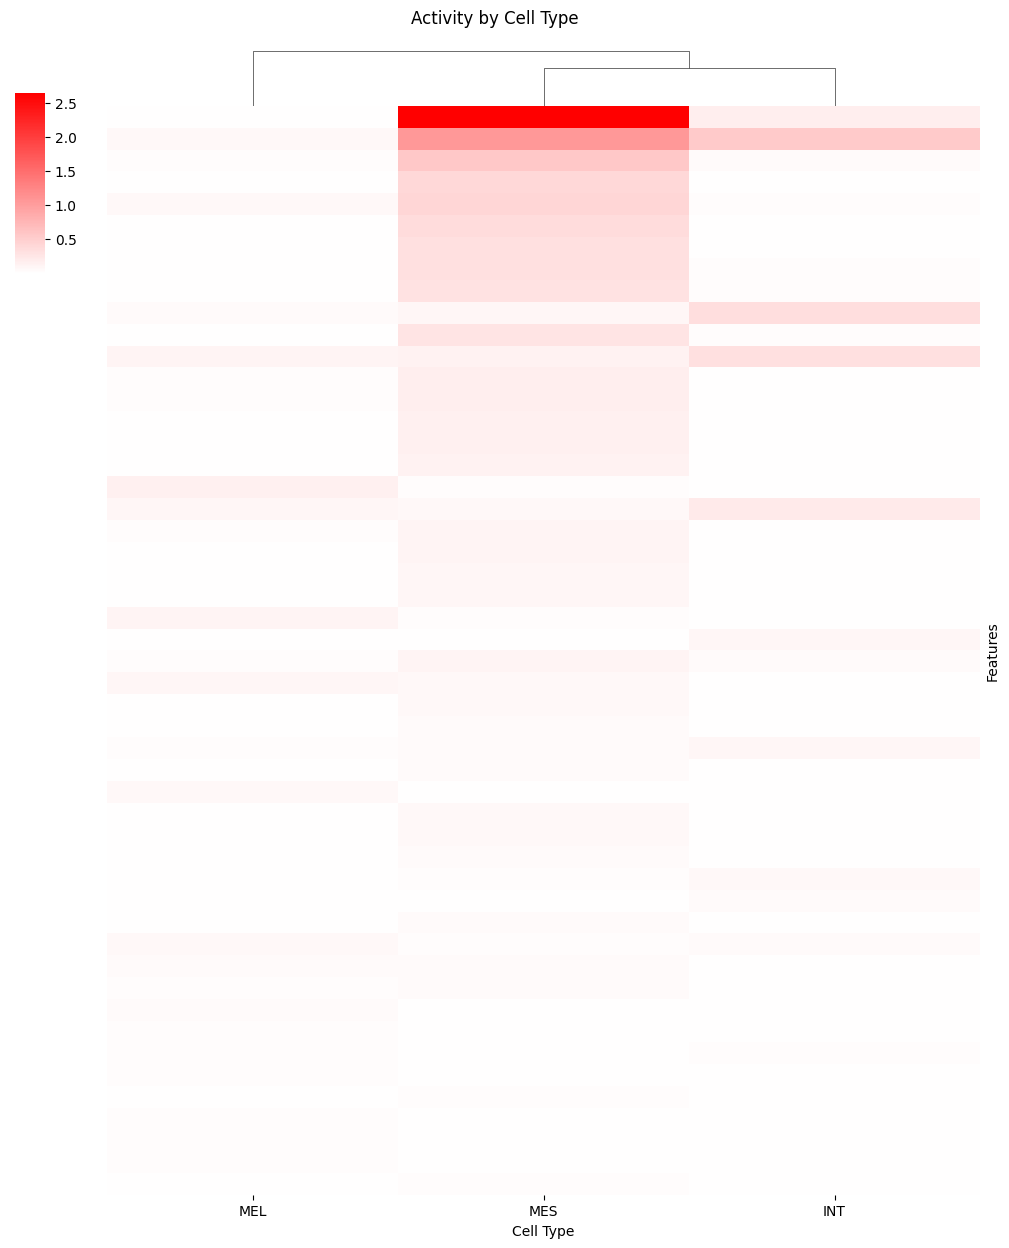

In [10]:
# Step 4: Compute TF activity scores weighted by active enhancers
tf_scores = ds.tl.compute_tf_activity_scores(model, mdata, celltype_key="cell_state", active_enhancers=active_enhancers)

# Visualize as heatmap
ds.pl.heatmap_celltype_activity(tf_scores, top_k=50)

### Interpreting the TF Activity Clustermap

In the clustermap above, look for:

1. **Cell-state-specific TF clusters**: TFs that are highly active in one state but not others
2. **Master regulators**: SOX10 and MITF should cluster together and show high activity in MEL cells
3. **MES regulators**: JUN-family TFs and ZEB1 should be active in MES cells
4. **Intermediate regulators**: If visible, INT cells may show a mix or have their own specific TFs

The hierarchical clustering on the left groups TFs by similar activity patterns across cell states, revealing the regulatory programs that define each phenotype.

In [11]:
# Step 5: Identify key TFs (union across cell types)
key_tfs = ds.tl.identify_key_tfs(tf_scores)
print(f"Identified {len(key_tfs)} key TFs: {key_tfs[:10]}...")

NameError: name 'tf_scores' is not defined

In [ ]:
# Step 6: Build focused GRN for key TFs only
focused_grn = ds.tl.build_grn_for_tfs(model, key_tfs)
print(f"Focused GRN: {len(focused_grn)} edges")
focused_grn.head(10)

## Network Visualization

Network graphs show the GRN structure as connected nodes.

In [ ]:
# Visualize full GRN as network
ds.pl.network_grn(model, top_k=50)

In [ ]:
# TF-centric network: show targets of a specific TF
ds.pl.network_tf_targets(model, tf="SOX10", top_k=20)

In [ ]:
# Gene-centric network: show regulators of a specific gene
ds.pl.network_gene_regulators(model, gene="MITF", top_k=10)

## Next Steps

Now that you've extracted and visualized the GRN:

- Simulate perturbation experiments: {doc}`05_perturbation_analysis`
- Explore advanced genomic visualizations: {doc}`06_advanced_visualization`